In [1]:
import sys
sys.path.insert(0, '/home/rudra/Documents/NeuralFieldManifold')

In [2]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

from NeuralFieldManifold.models import DeepLagEmbed
from NeuralFieldManifold.generators import tvar
from NeuralFieldManifold.utils import train_loop, bench_loop
from NeuralFieldManifold.plottings import plot_history, plot_coefficients_by_p, plot_tvar_sample
from torchinfo import summary

from utils import pinn_processor

In [6]:
X_train, coef_train, p_train, class_id_train, X_val, coef_val, p_val, class_id_val, class_names = pinn_processor("train_data.npz", family=None)

Total samples: 1000000 | Train: 800000 | Val: 200000
Train p distribution: {np.int64(0): np.int64(160000), np.int64(1): np.int64(160000), np.int64(2): np.int64(160000), np.int64(3): np.int64(160000), np.int64(4): np.int64(160000)}
Val p distribution:   {np.int64(0): np.int64(40000), np.int64(1): np.int64(40000), np.int64(2): np.int64(40000), np.int64(3): np.int64(40000), np.int64(4): np.int64(40000)}


In [3]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.cuda.init()
    torch.backends.cudnn.benchmark = True
    print(f"Using device: {device}")

# Move ALL data to GPU upfront - eliminates CPU->GPU transfer bottleneck
X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
p_train = torch.tensor(p_train, dtype=torch.long, device=device)
X_val = torch.tensor(X_val, dtype=torch.float32, device=device)
p_val = torch.tensor(p_val, dtype=torch.long, device=device)
class_id_val = class_id_val  # numpy array

# Data already on GPU - no pin_memory/workers needed
train_loader = DataLoader(
    TensorDataset(X_train, p_train), 
    batch_size=256,
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val, p_val), 
    batch_size=256
)

Using device: cuda:1


In [4]:
def do_bench_on_config(lambda_config, model=None):
    
    # hyperparameters
    n_epochs = 100
    lr = 1e-3
    max_ar_order = 6
    
    if model is None:
        # Model: n_classes=5 for p∈{2,3,4,5,6}, max_ar_order=6 for coefficient dimensions
        model = DeepLagEmbed(seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128)
        model = model.to(device)
        # summary(model, input_size=(32, 600), device=device)

    # Train
    history = train_loop(
        model, train_loader, val_loader,
        n_epochs=n_epochs, lr=lr,
        lambda_p=lambda_config["lambda_p"], lambda_ar=lambda_config["lambda_ar"], lambda_energy=lambda_config["lambda_energy"], 
        lambda_smooth=lambda_config["lambda_smooth"], lambda_order=lambda_config["lambda_order"],
        p_max=max_ar_order, device=device
    )
    return model, history

## Base fit

Training: 100%|██████████| 100/100 [14:56<00:00,  8.96s/it, p_acc=0.340, train=6.5934, val=8.4380]


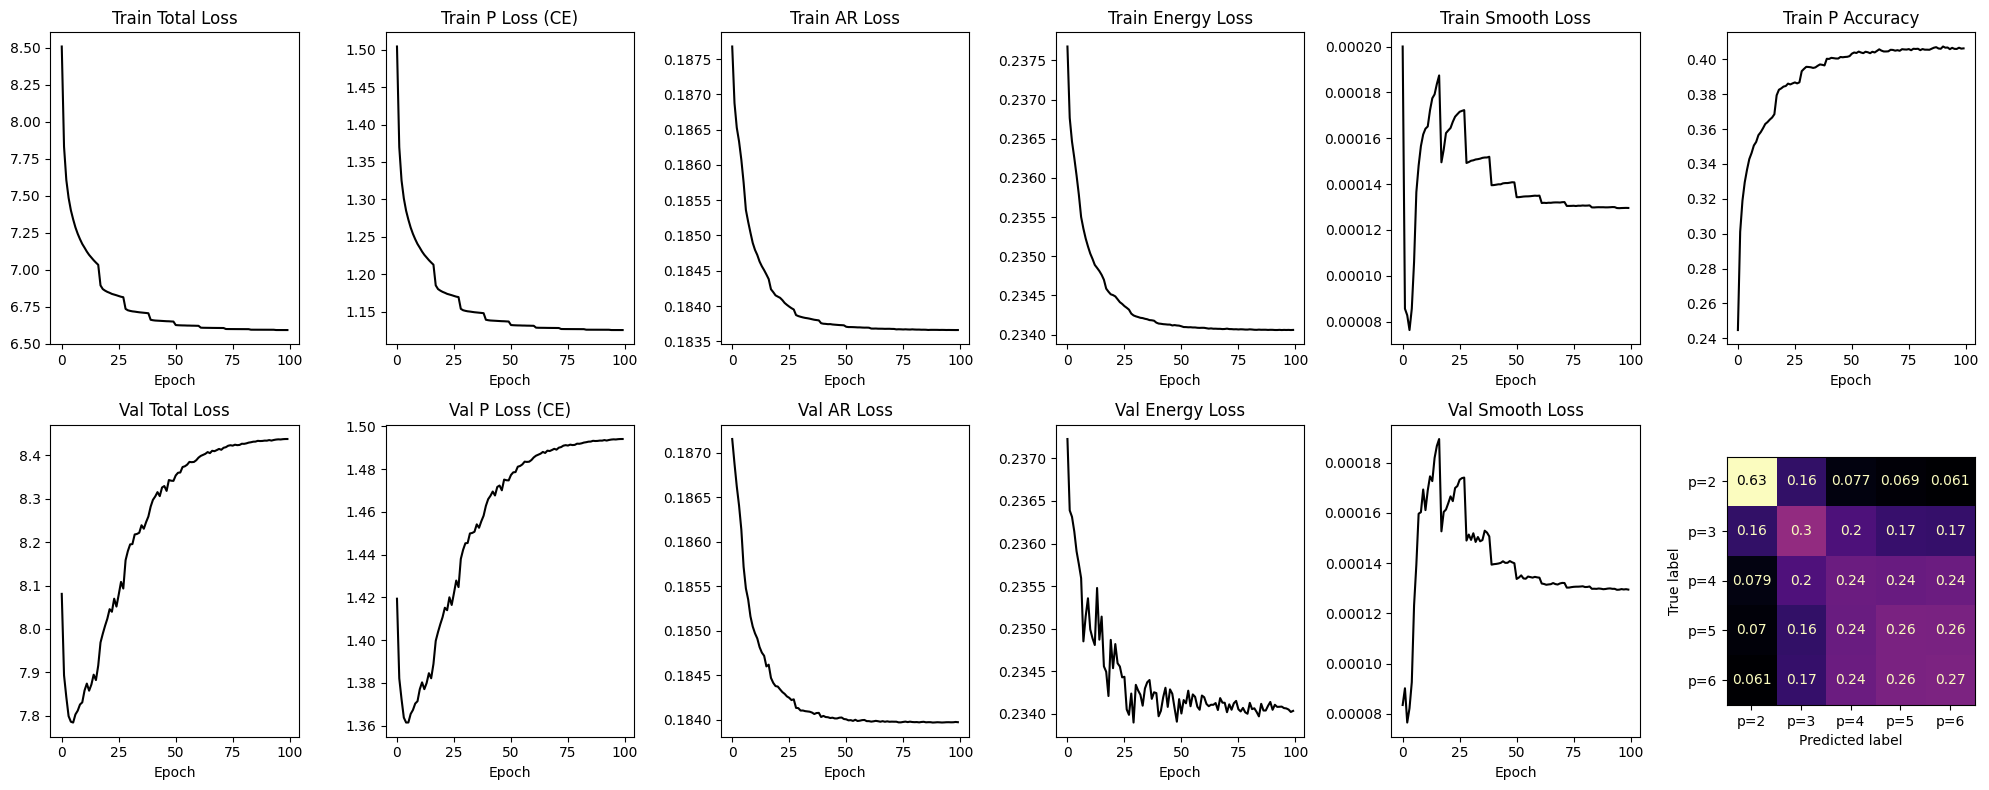

In [5]:
conf = {
    "lambda_ar": 5,
    "lambda_p": 5,
    "lambda_order": 0,
    "lambda_energy": 0.2,
    "lambda_smooth": 5,
}

model, history = do_bench_on_config(conf)
plot_history(history, model=model, val_loader=val_loader, device=device)

In [6]:
# Save model
torch.save(model.state_dict(), "base_model.pt")
print("Model saved to base_model.pt")

Model saved to base_model.pt


In [7]:
# # # Load model
# model = DeepLagEmbed(seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128)
# model.load_state_dict(torch.load("base_model.pt", map_location=device))
# model = model.to(device)
# model.eval()
# print("Model loaded from base_model.pt")

In [8]:
# Get predictions on full validation set
model.eval()
all_p_pred = []
all_p_true = []

with torch.no_grad():
    for x_batch, p_batch in tqdm(val_loader, desc="Getting predictions"):
        x_batch = x_batch.to(device)
        _, _, p_hard, _ = model(x_batch)
        all_p_pred.extend(p_hard.cpu().numpy())
        all_p_true.extend(p_batch.cpu().numpy())

all_p_pred = np.array(all_p_pred)
all_p_true = np.array(all_p_true)

Getting predictions: 100%|██████████| 782/782 [00:00<00:00, 795.68it/s]


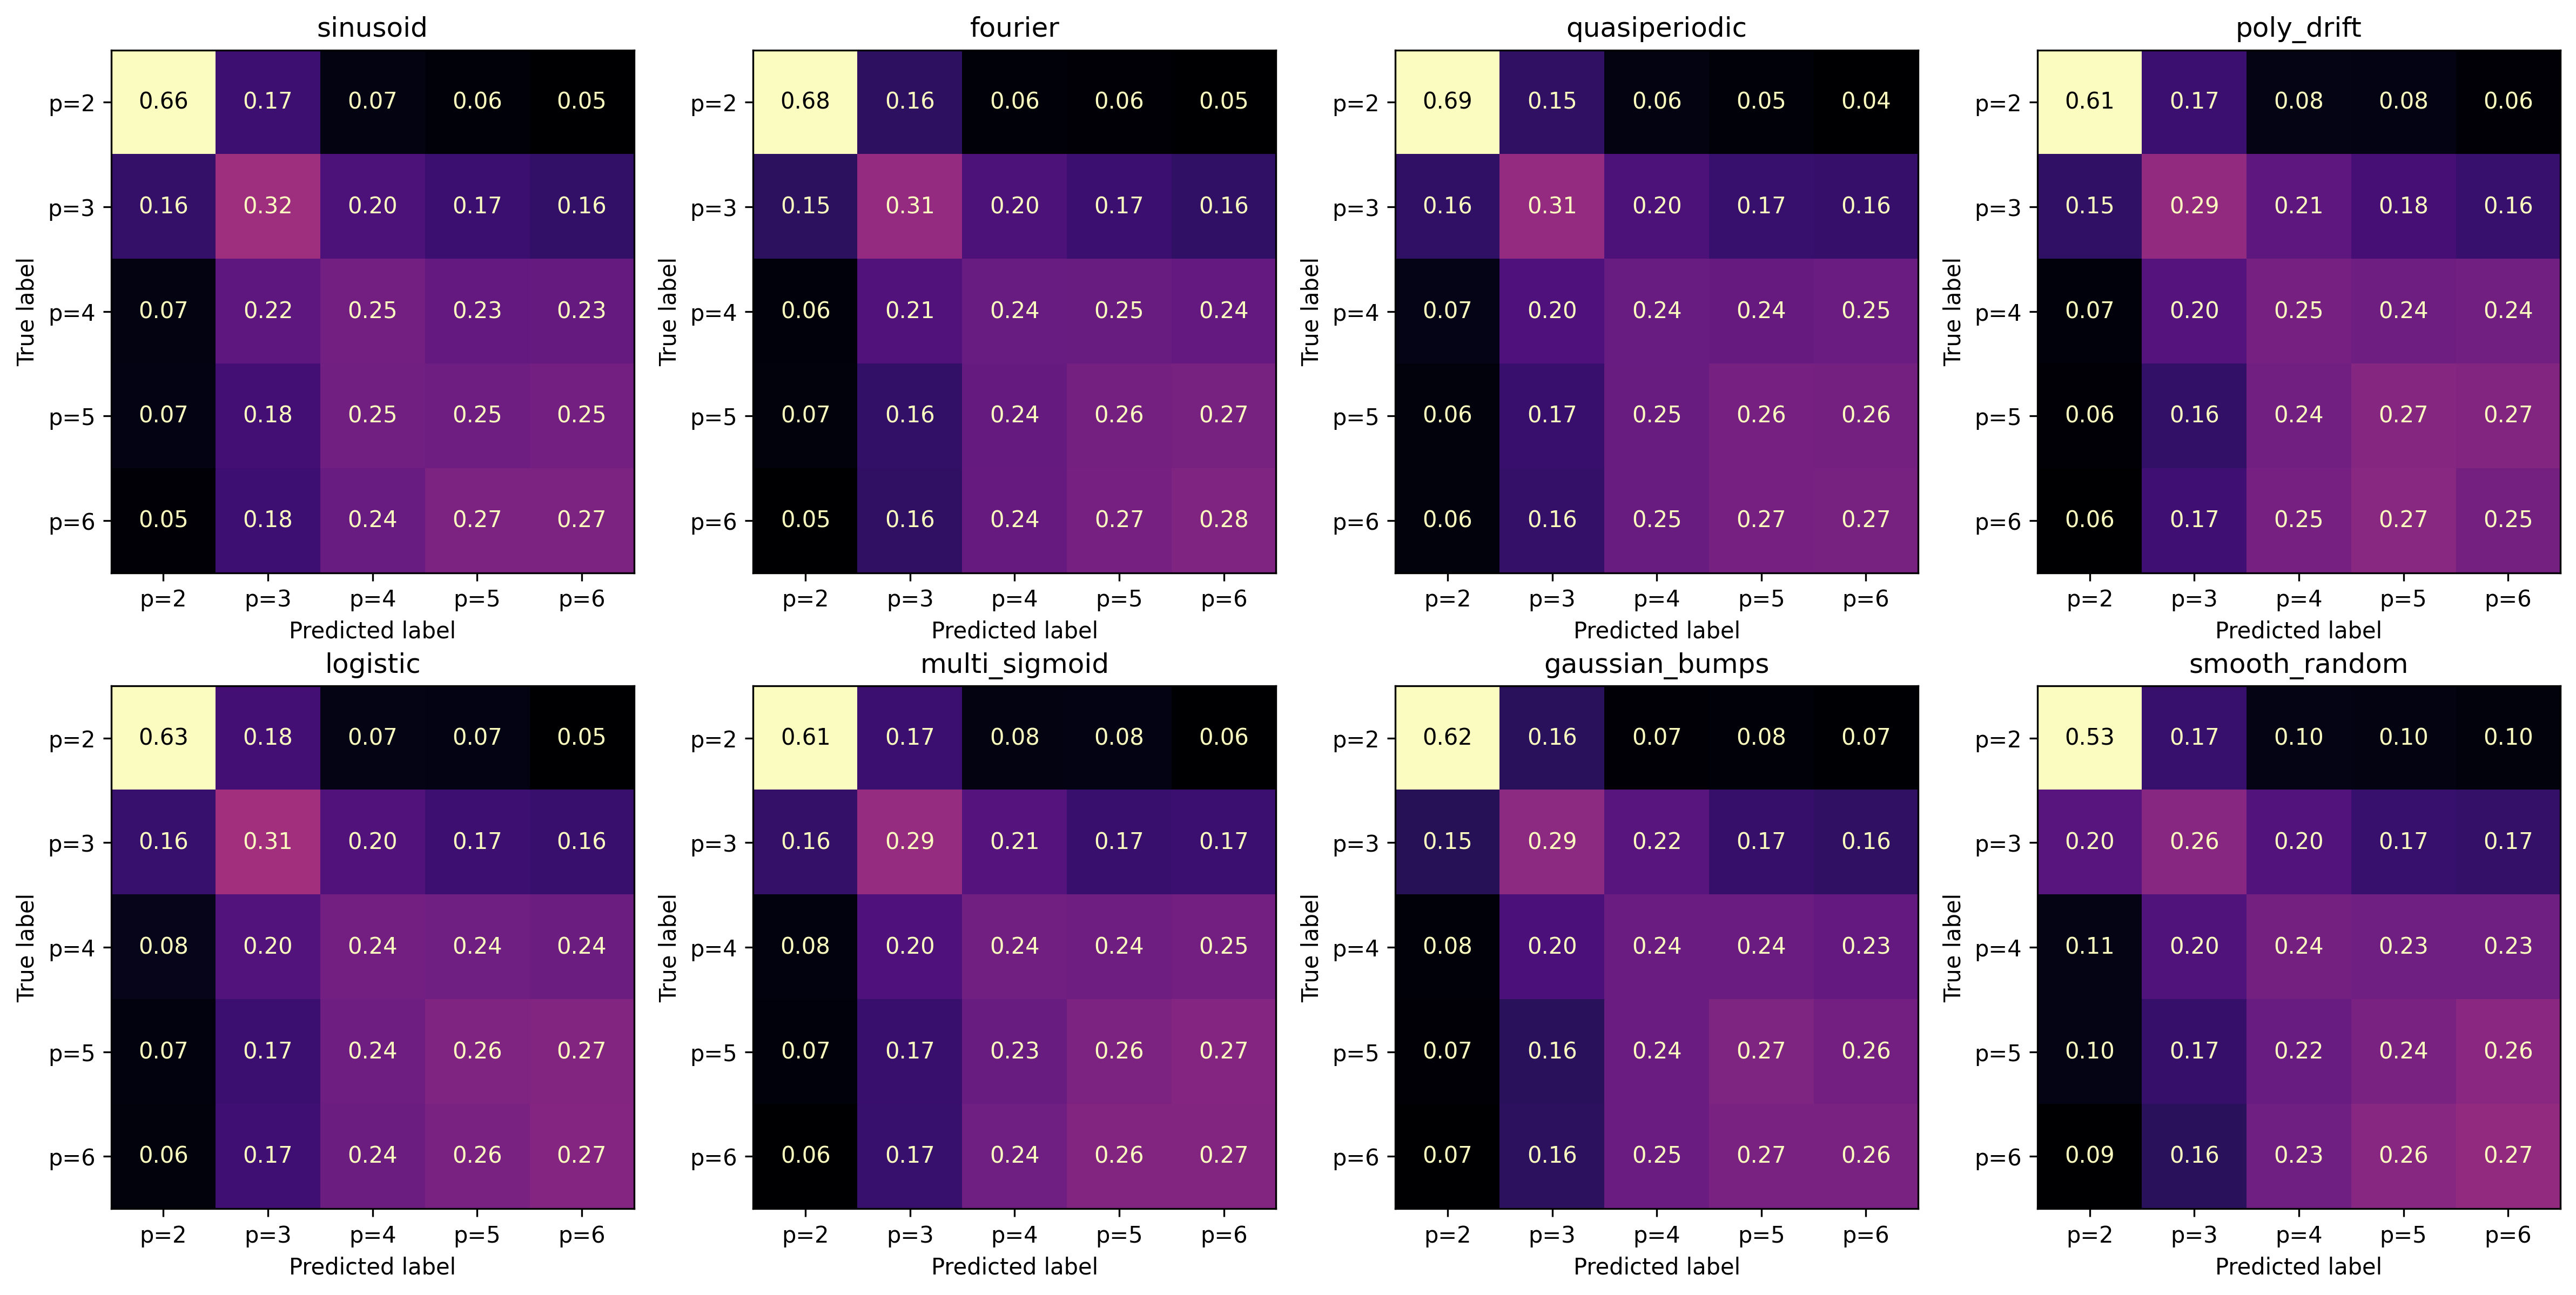

In [9]:
# Plot confusion matrix for each signal family
n_families = len(class_names)
nrows, ncols = 2, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), dpi=300)
axes_flat = axes.flatten()

p_min, p_max = 2, 6
n_classes = p_max - p_min + 1

family_results = {}

for i, family_name in enumerate(class_names):
    mask = class_id_val == i
    p_true_family = all_p_true[mask]
    p_pred_family = all_p_pred[mask]
    
    # Compute normalized confusion matrix
    cm = confusion_matrix(p_true_family, p_pred_family, labels=range(n_classes))
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    
    # Store accuracy for this family
    family_results[family_name] = {
        'accuracy': np.mean(p_true_family == p_pred_family),
        'n_samples': len(p_true_family)
    }
    
    # Plot
    disp = ConfusionMatrixDisplay(cm_norm, display_labels=[f'p={j+p_min}' for j in range(n_classes)])
    disp.plot(ax=axes_flat[i], cmap='magma', colorbar=False, values_format='.2f')
    axes_flat[i].set_title(f'{family_name}')

# Hide unused subplots
for j in range(n_families, nrows * ncols):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
family_bench_results = {}

for i, family_name in enumerate(class_names):
    mask = class_id_val == i
    X_family = X_val[mask].cpu()  # Move to CPU for bench_loop
    coef_family = coef_val[mask][:, :, :6]  # Slice to max_ar_order=6
    p_family = p_val[mask].cpu()
    
    results = bench_loop(model, X_family, coef_family, p_family, device)
    family_bench_results[family_name] = results

# Display as DataFrame
family_bench_df = pd.DataFrame(family_bench_results).T
family_df = family_bench_df.rename(columns={
    'coeff_mse': 'coeff mse',
    'signal_mse': 'signal mse',
    'p_mae': 'delta p',
    'p_mape': 'delta p / p',
    'p2_acc': 'p=2',
    'p3_acc': 'p=3',
    'p4_acc': 'p=4',
    'p5_acc': 'p=5',
    'p6_acc': 'p=6',
    'p_acc': 'P Avg.',
})
family_bench_df

,coeff_mse,signal_mse,p_mae,p_mape,p2_acc,p3_acc,p4_acc,p5_acc,p6_acc,p_acc
sinusoid,0.003924,0.183046,1.085483,0.290002,0.661209,0.326721,0.241122,0.251023,0.267625,0.351111
fourier,0.004272,0.184083,1.069846,0.284058,0.679984,0.316788,0.244737,0.274840,0.280372,0.358101
quasiperiodic,0.004035,0.182153,1.063116,0.281938,0.684039,0.310689,0.247123,0.272243,0.277012,0.356821
poly_drift,0.004315,0.183816,1.109580,0.302322,0.618354,0.300617,0.248848,0.262569,0.266481,0.340402
logistic,0.003673,0.183003,1.106807,0.300061,0.629938,0.296878,0.240559,0.260685,0.267918,0.339890
multi_sigmoid,0.003155,0.182505,1.132916,0.309419,0.607890,0.296363,0.244748,0.260765,0.269086,0.336374
gaussian_bumps,0.003542,0.183888,1.123097,0.302140,0.624358,0.305849,0.248492,0.266004,0.264642,0.340380
smooth_random,0.007759,0.189260,1.221906,0.343524,0.523409,0.258195,0.228875,0.251690,0.265594,0.305647


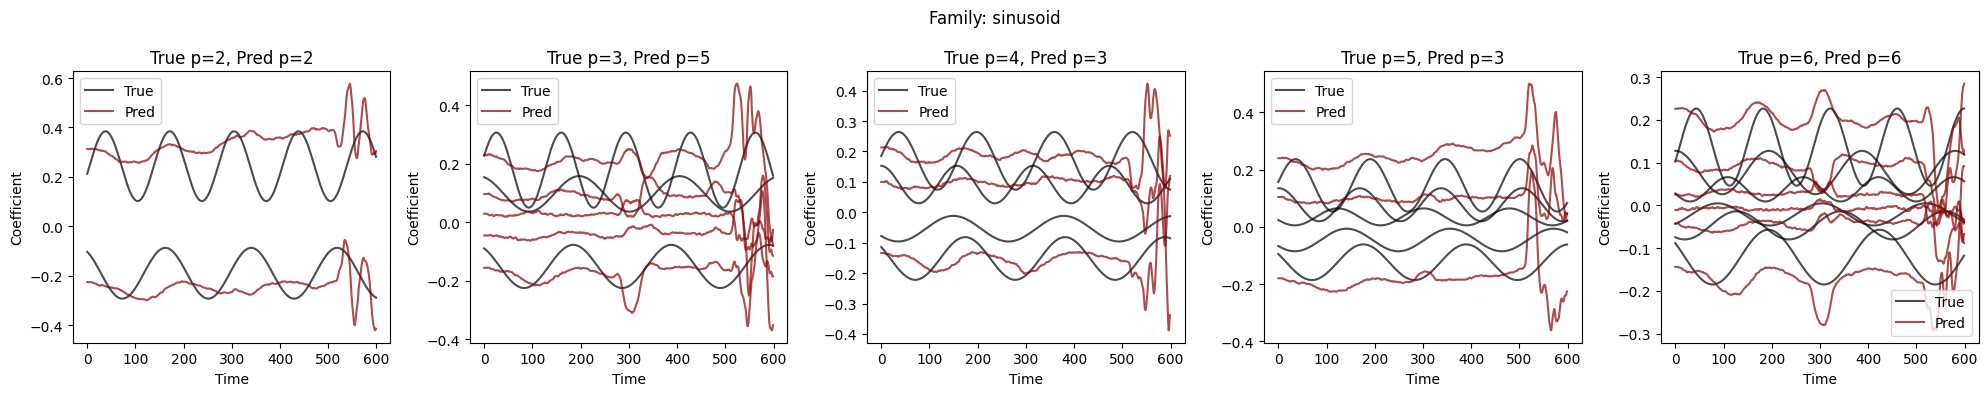

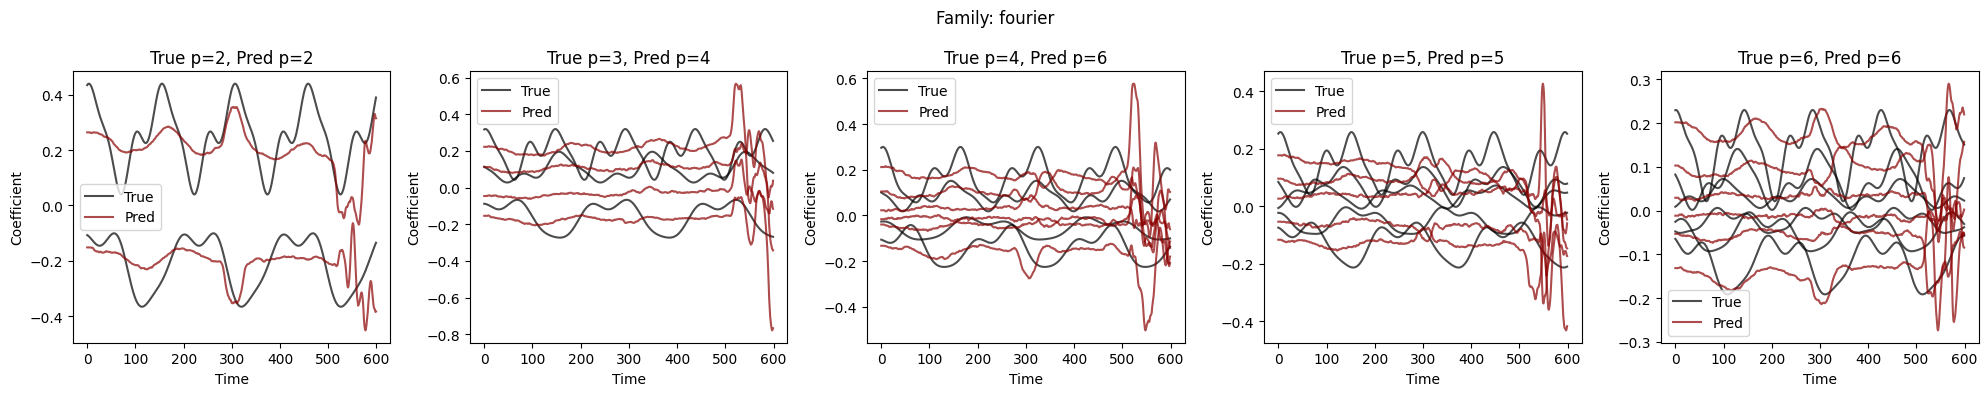

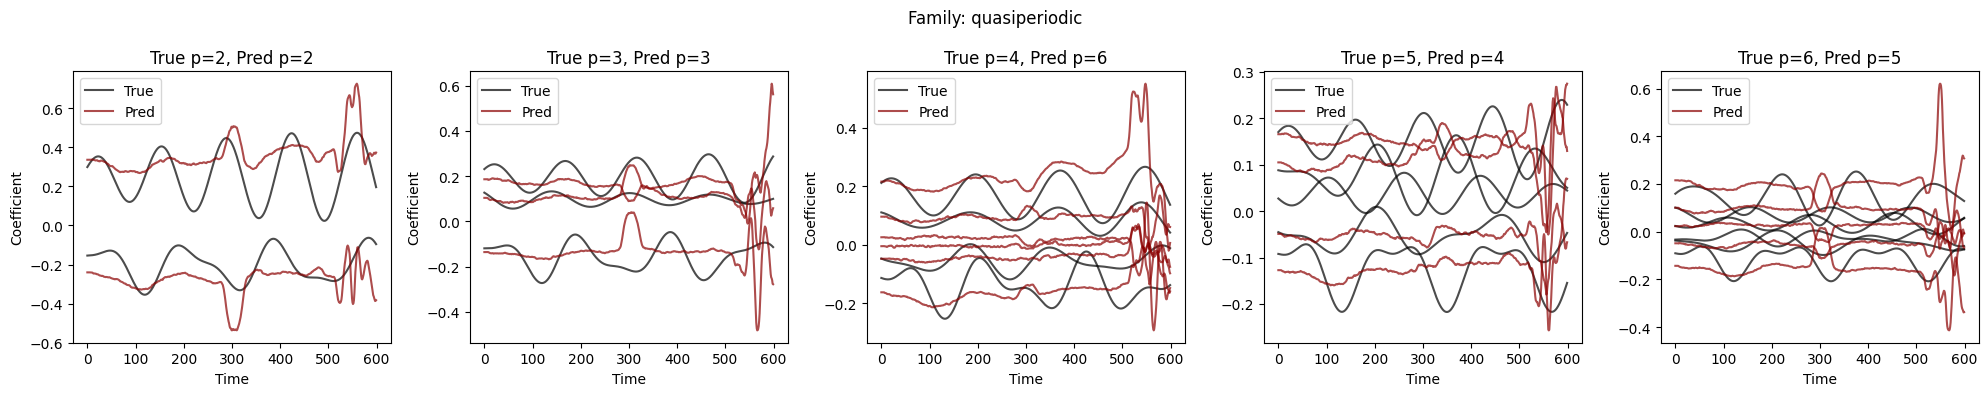

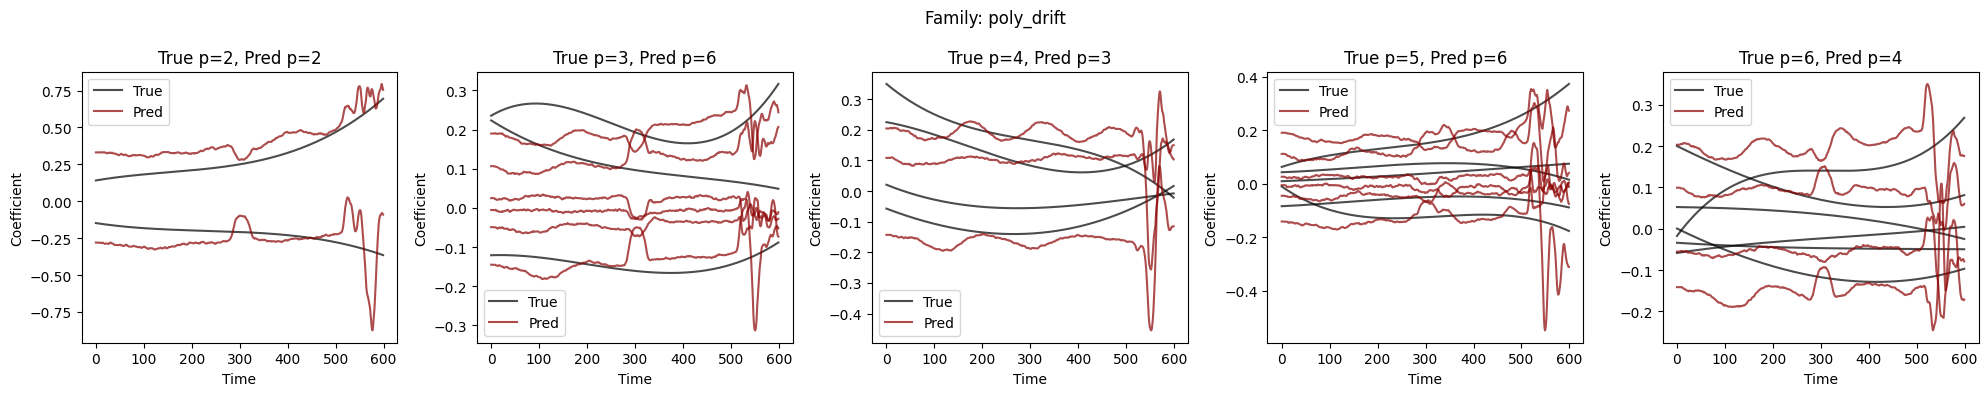

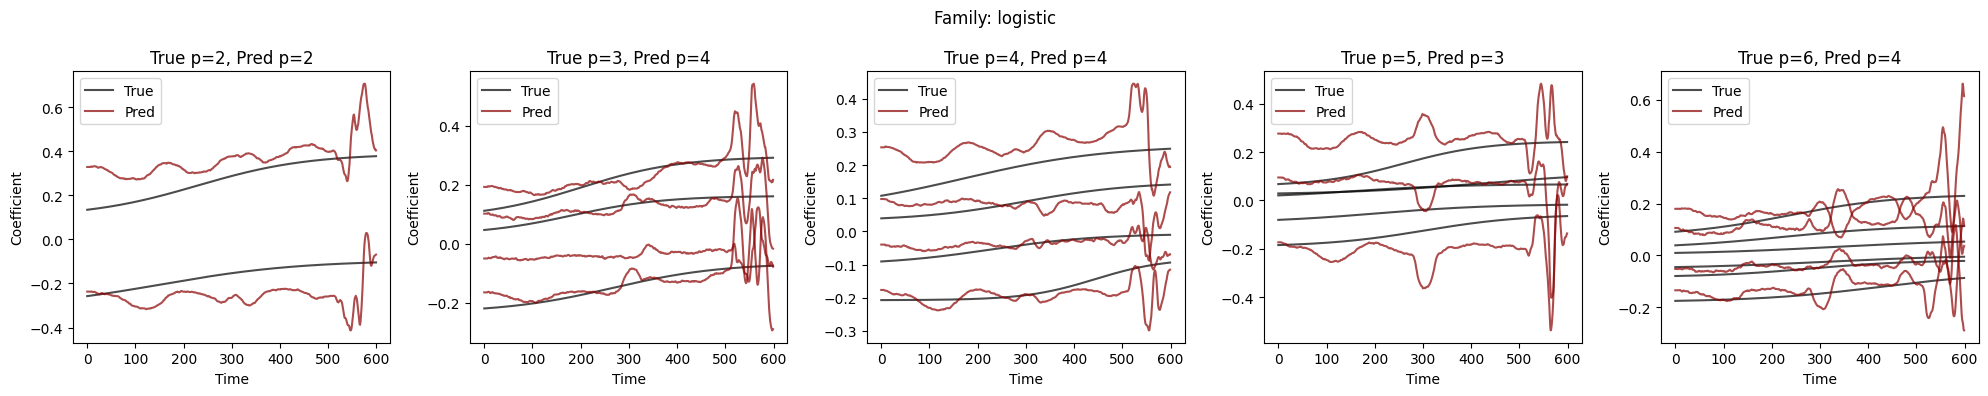

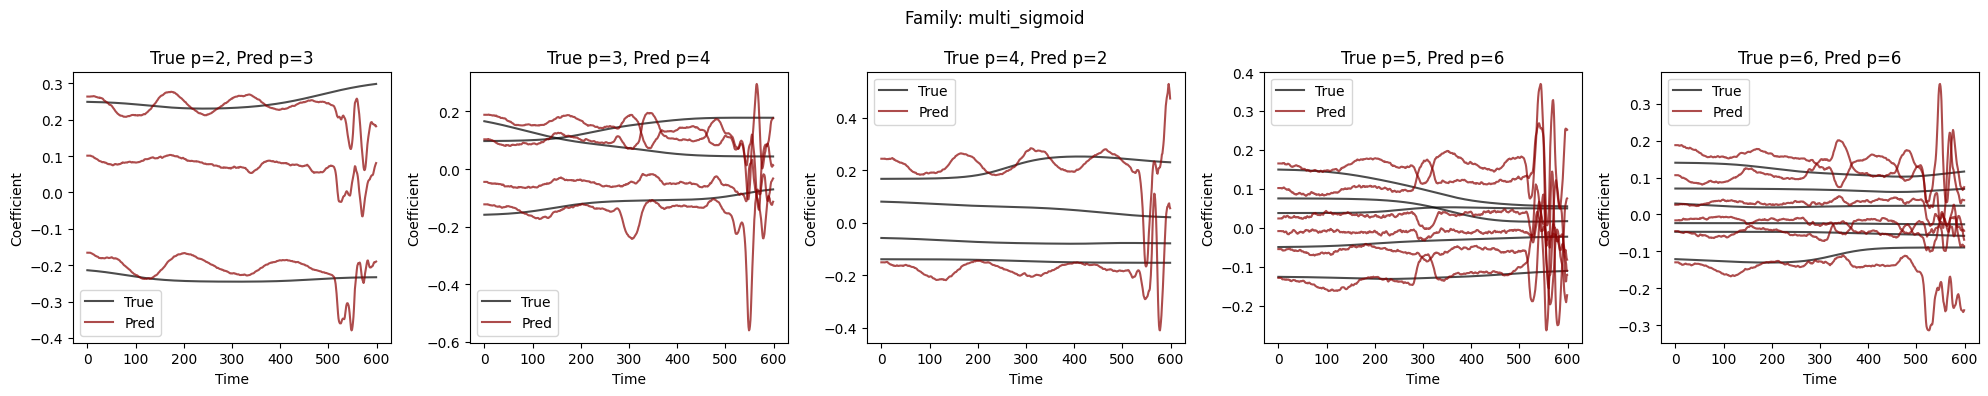

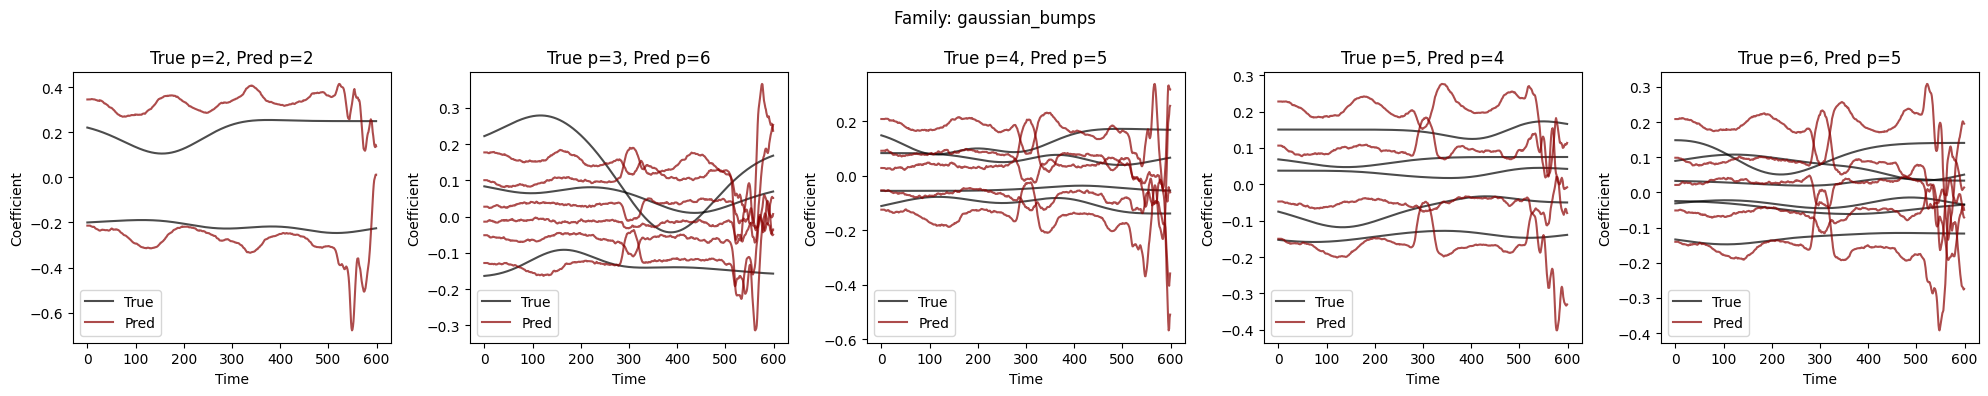

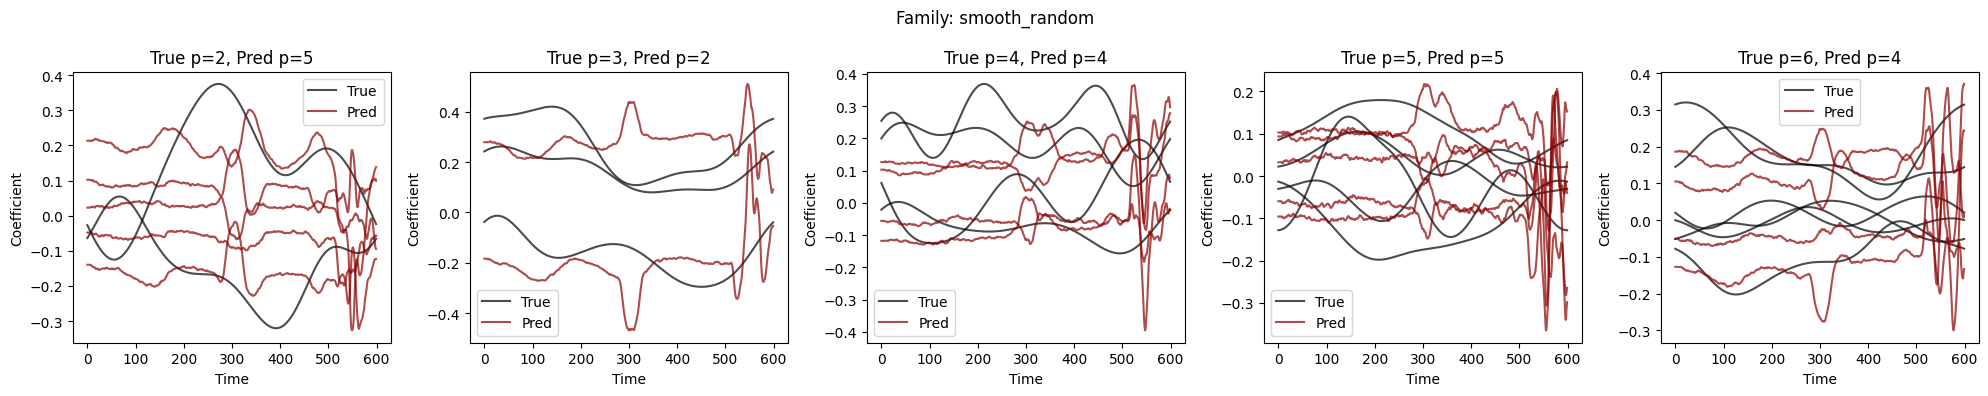

In [11]:
# Plot coefficient predictions for each signal family
for i, family_name in enumerate(class_names):
    mask = class_id_val == i
    X_family = X_val[mask].cpu()  
    coef_family = coef_val[mask][:, :, :6]
    p_family = p_val[mask].cpu()
    
    plot_coefficients_by_p(model, X_family, coef_family, p_family, device, 
                           p_max=6, p_min=2, title=f"Family: {family_name}")

## Ablation study

In [ ]:
# Full Model
# No AR(P)
# No P CE 
# No Energy
# No Smooth

ablation_config = {
    "full": {
        "lambda_ar": 5,
        "lambda_p": 5,
        "lambda_order": 0,
        "lambda_energy": 0.2,
        "lambda_smooth": 5,
    },
    "no_ar": {
        # "lambda_ar": 0,
        "lambda_p": 5,
        "lambda_order": 0,
        "lambda_energy": 0.2,
        "lambda_smooth": 5,
    },
    "no_p": {
        "lambda_ar": 5,
        "lambda_p": 0,
        "lambda_order": 0,
        "lambda_energy": 0.2,
        "lambda_smooth": 5,
    },
    "no_energy": {
        "lambda_ar": 5,
        "lambda_p": 5,
        "lambda_order": 0,
        "lambda_energy": 0,
        "lambda_smooth": 5,
    },
    "no_smooth": {
        "lambda_ar": 5,
        "lambda_p": 5,
        "lambda_order": 0,
        "lambda_energy": 0.2,
        "lambda_smooth": 0,
    }
}



  Ablation: full
  Config: {'lambda_ar': 5, 'lambda_p': 5, 'lambda_order': 0, 'lambda_energy': 0.2, 'lambda_smooth': 5}



Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training: 100%|██████████| 100/100 [15:01<00:00,  9.02s/it, p_acc=0.340, train=6.5852, val=8.4291]


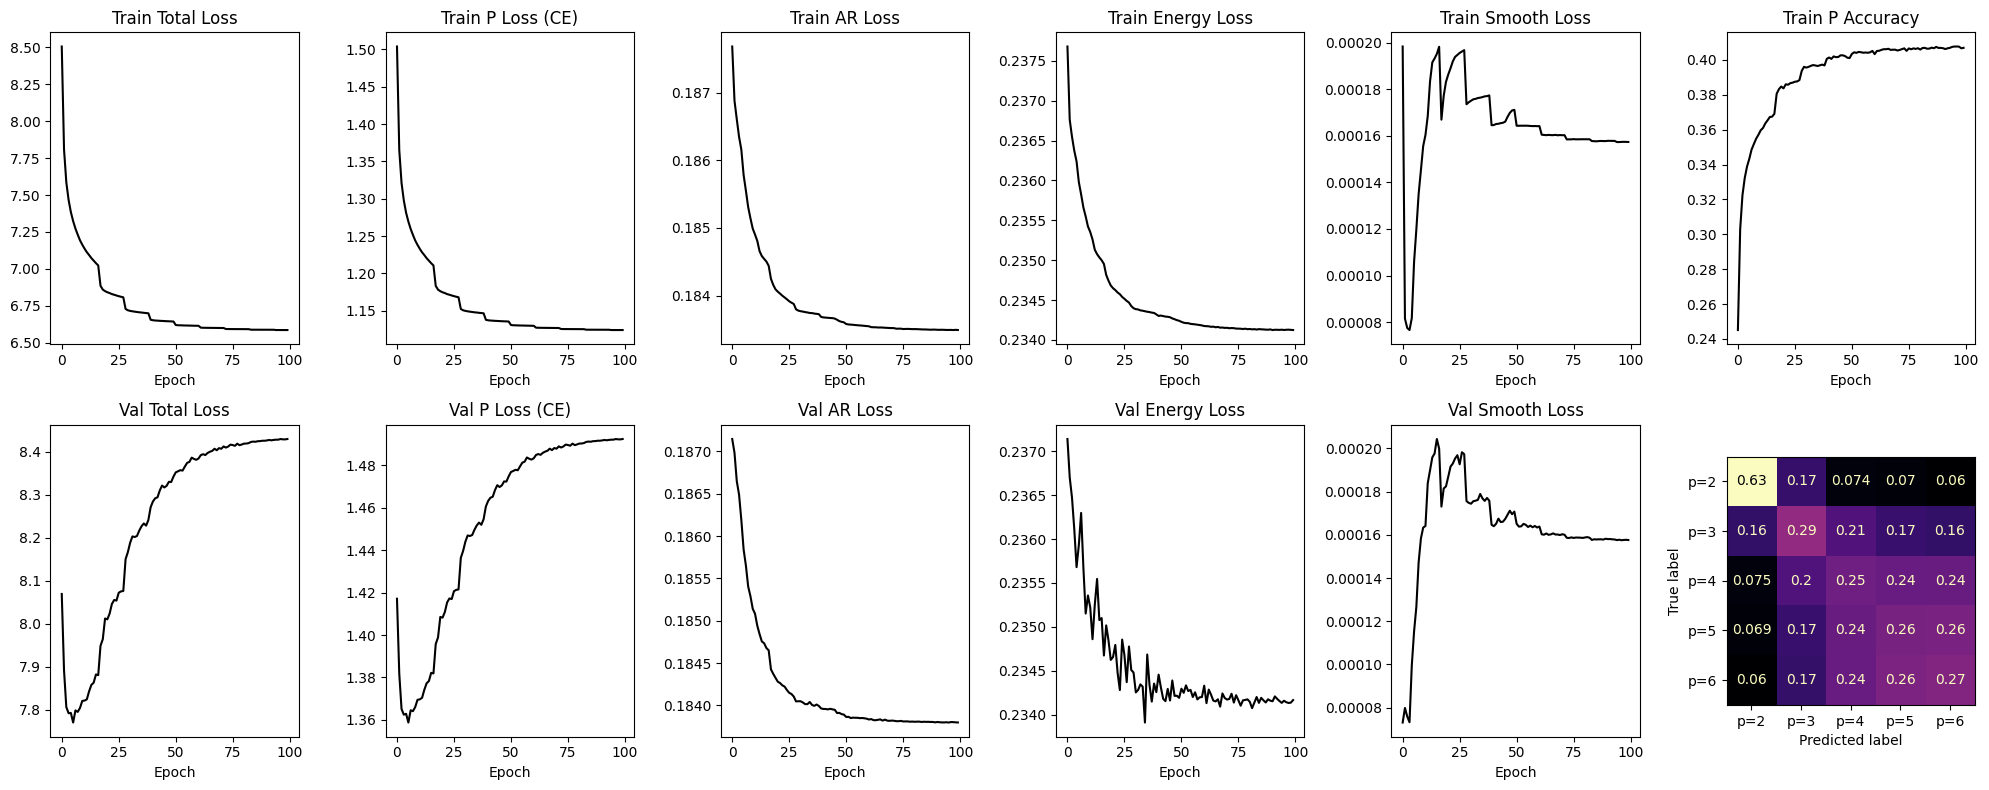


  Ablation: no_ar
  Config: {'lambda_ar': 0, 'lambda_p': 5, 'lambda_order': 0, 'lambda_energy': 0.2, 'lambda_smooth': 5}



Training: 100%|██████████| 100/100 [15:01<00:00,  9.01s/it, p_acc=0.343, train=5.6242, val=7.3992]


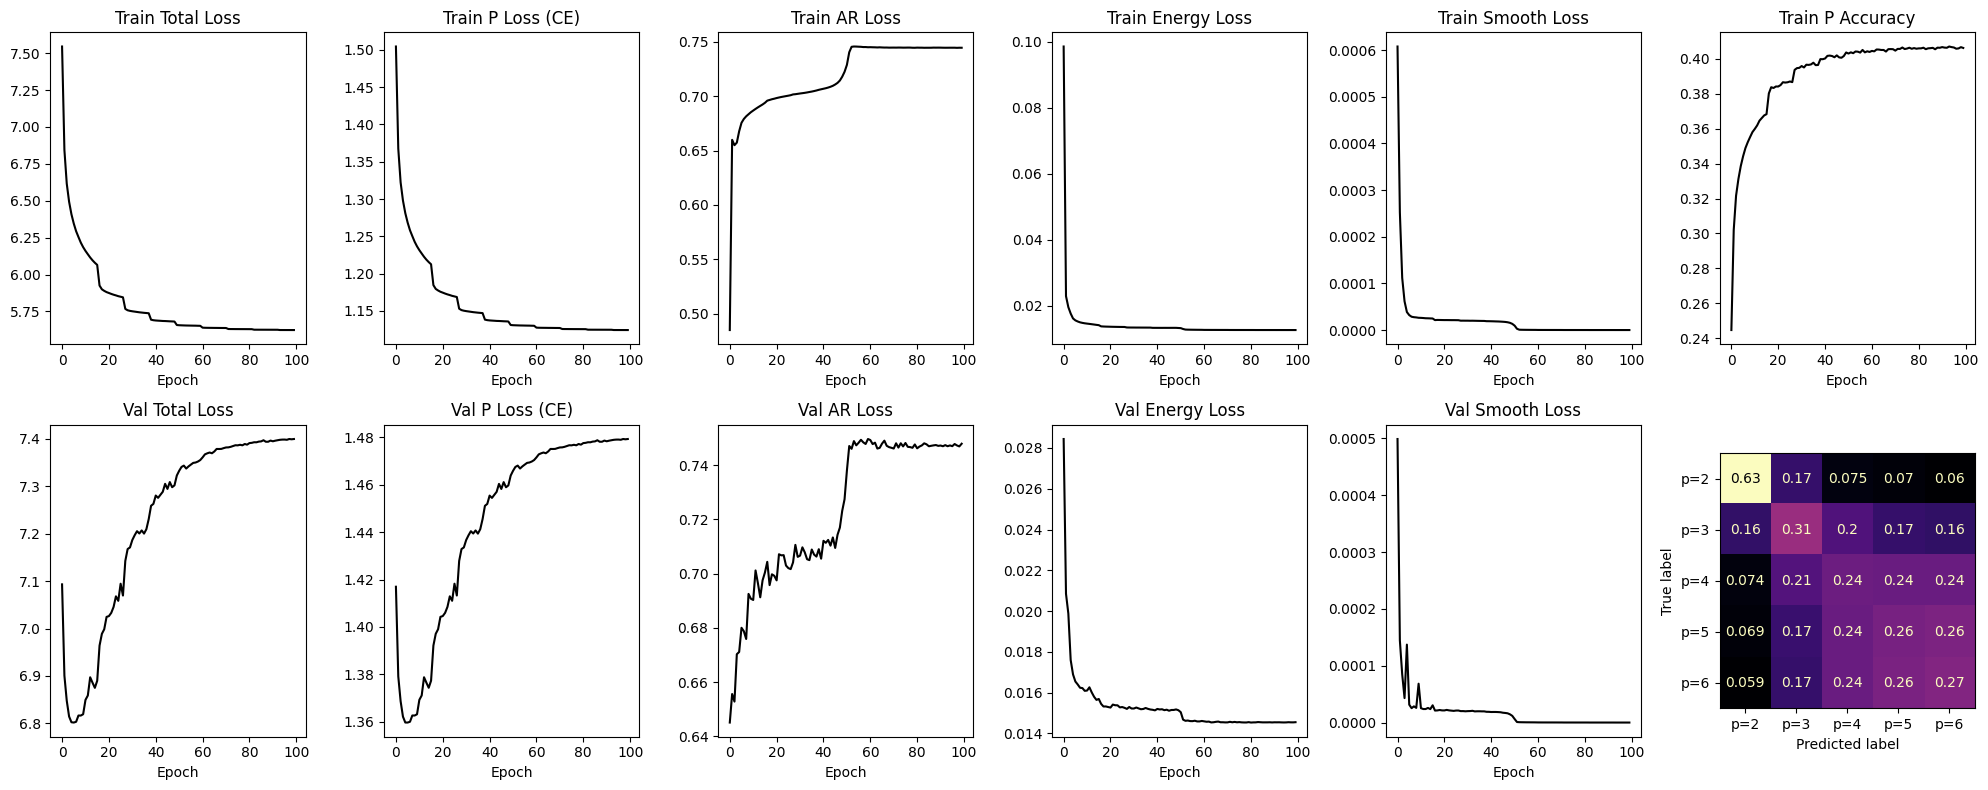


  Ablation: no_p
  Config: {'lambda_ar': 5, 'lambda_p': 0, 'lambda_order': 0, 'lambda_energy': 0.2, 'lambda_smooth': 5}



Training: 100%|██████████| 100/100 [15:04<00:00,  9.04s/it, p_acc=0.193, train=0.9642, val=0.9653]


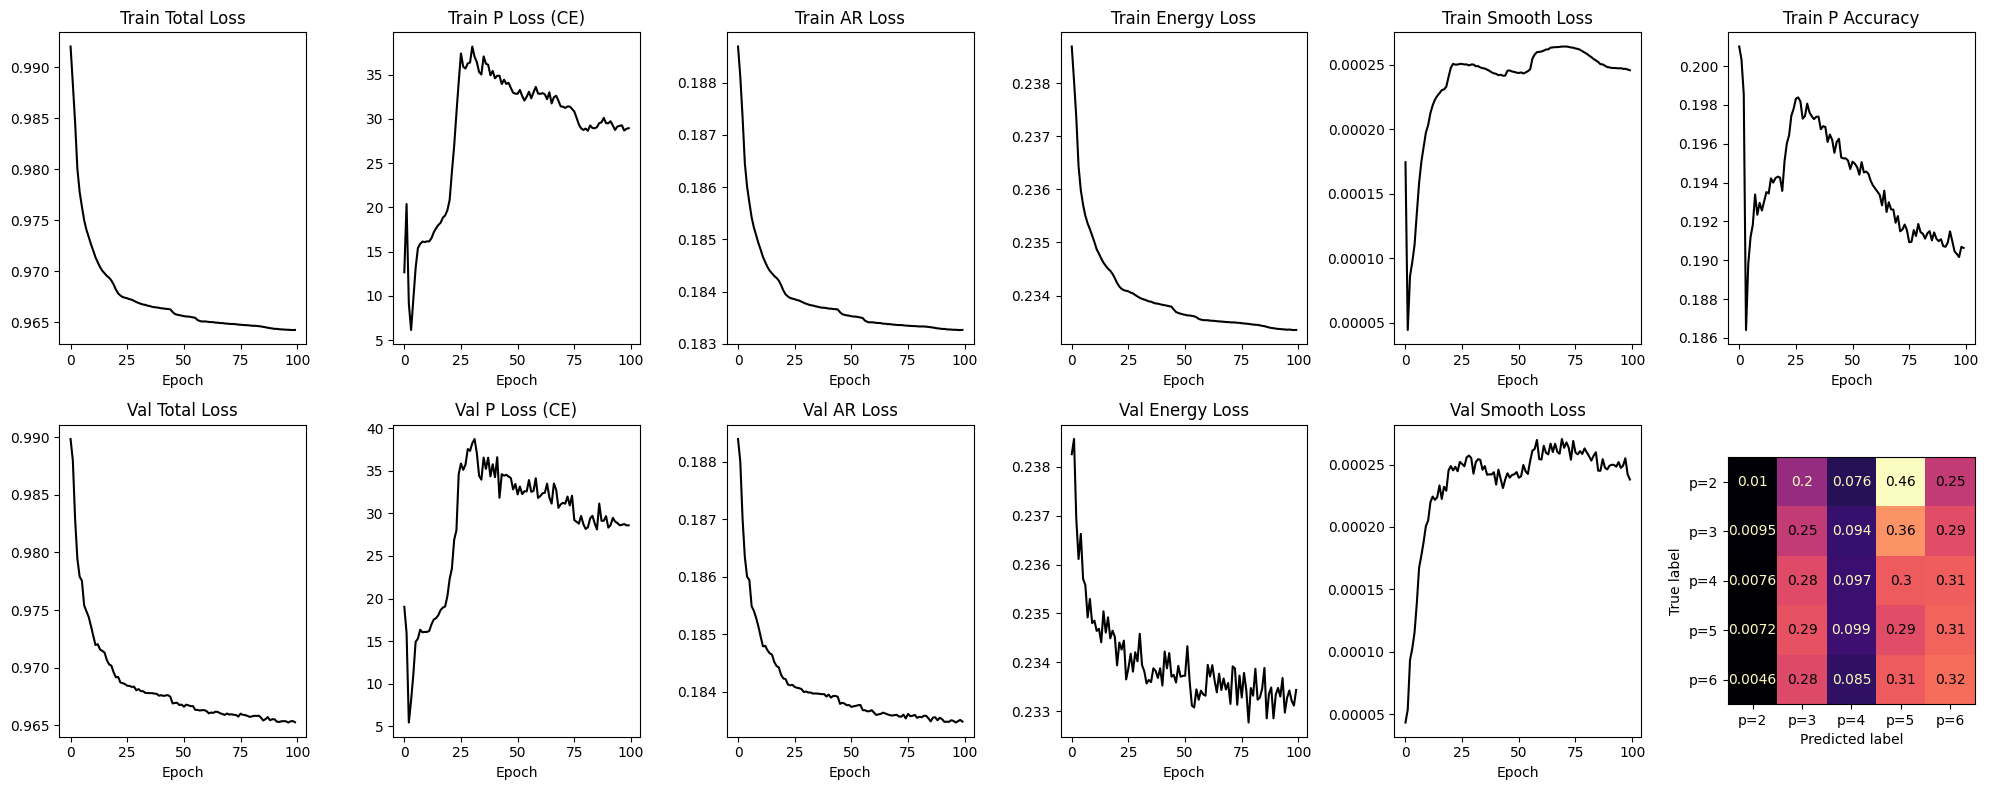


  Ablation: no_energy
  Config: {'lambda_ar': 5, 'lambda_p': 5, 'lambda_order': 0, 'lambda_energy': 0, 'lambda_smooth': 5}



Training: 100%|██████████| 100/100 [14:58<00:00,  8.99s/it, p_acc=0.341, train=6.5431, val=8.3640]


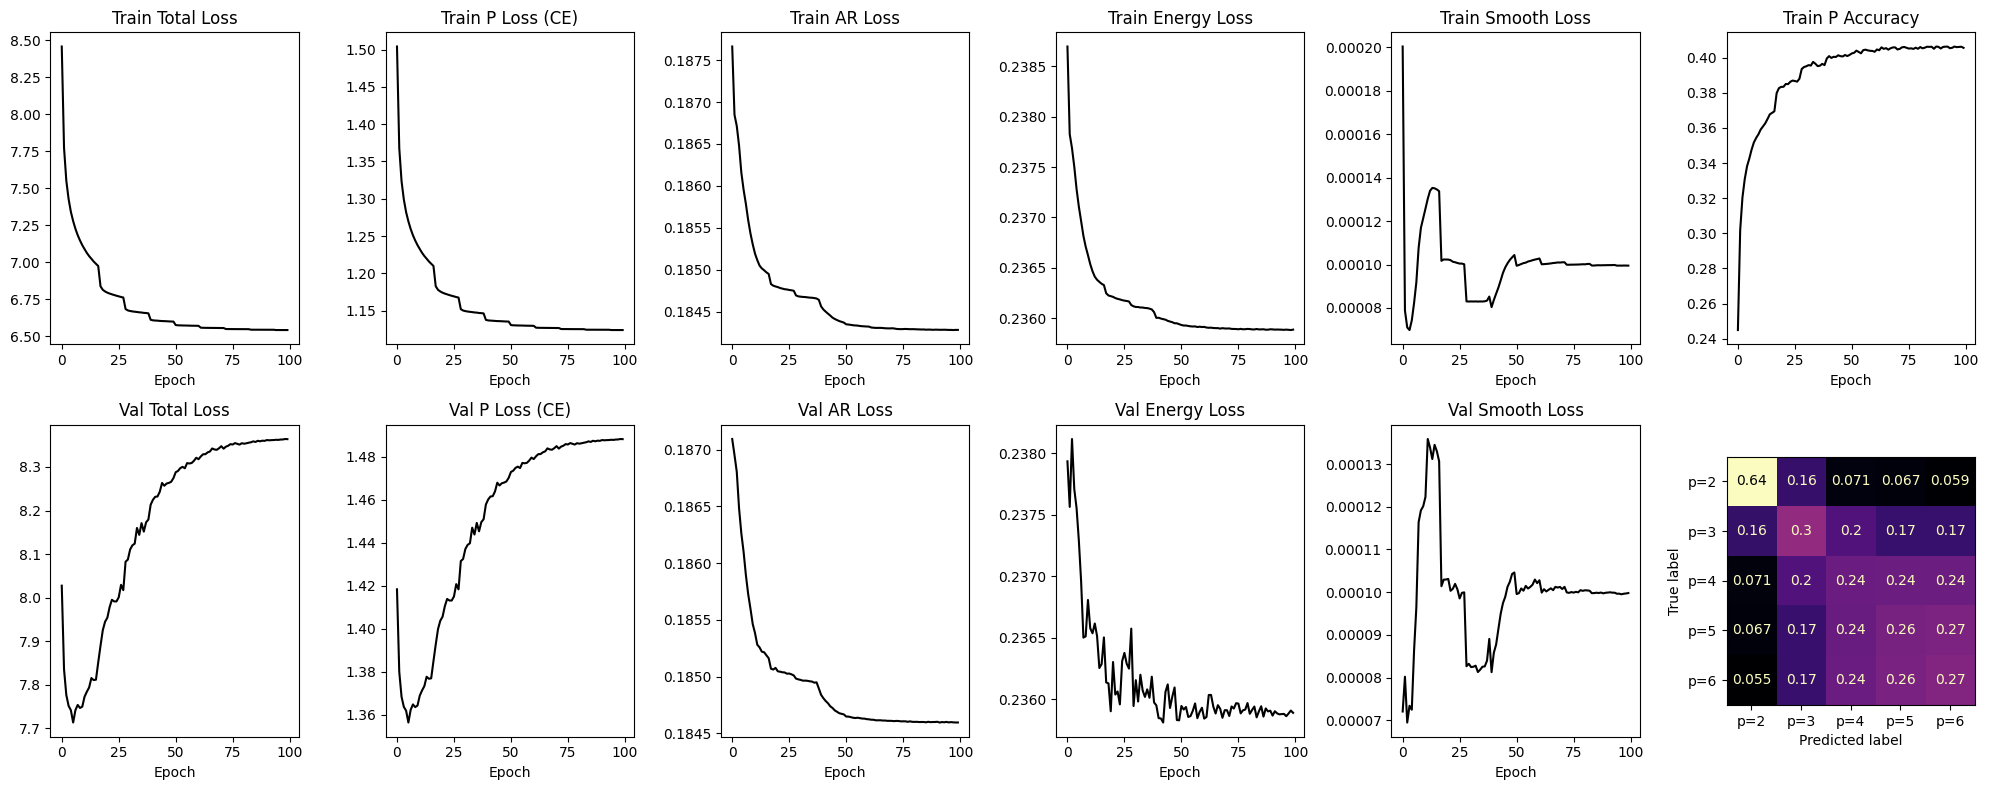


  Ablation: no_smooth
  Config: {'lambda_ar': 5, 'lambda_p': 5, 'lambda_order': 0, 'lambda_energy': 0.2, 'lambda_smooth': 0}



Training: 100%|██████████| 100/100 [15:05<00:00,  9.06s/it, p_acc=0.340, train=6.5777, val=8.3416]


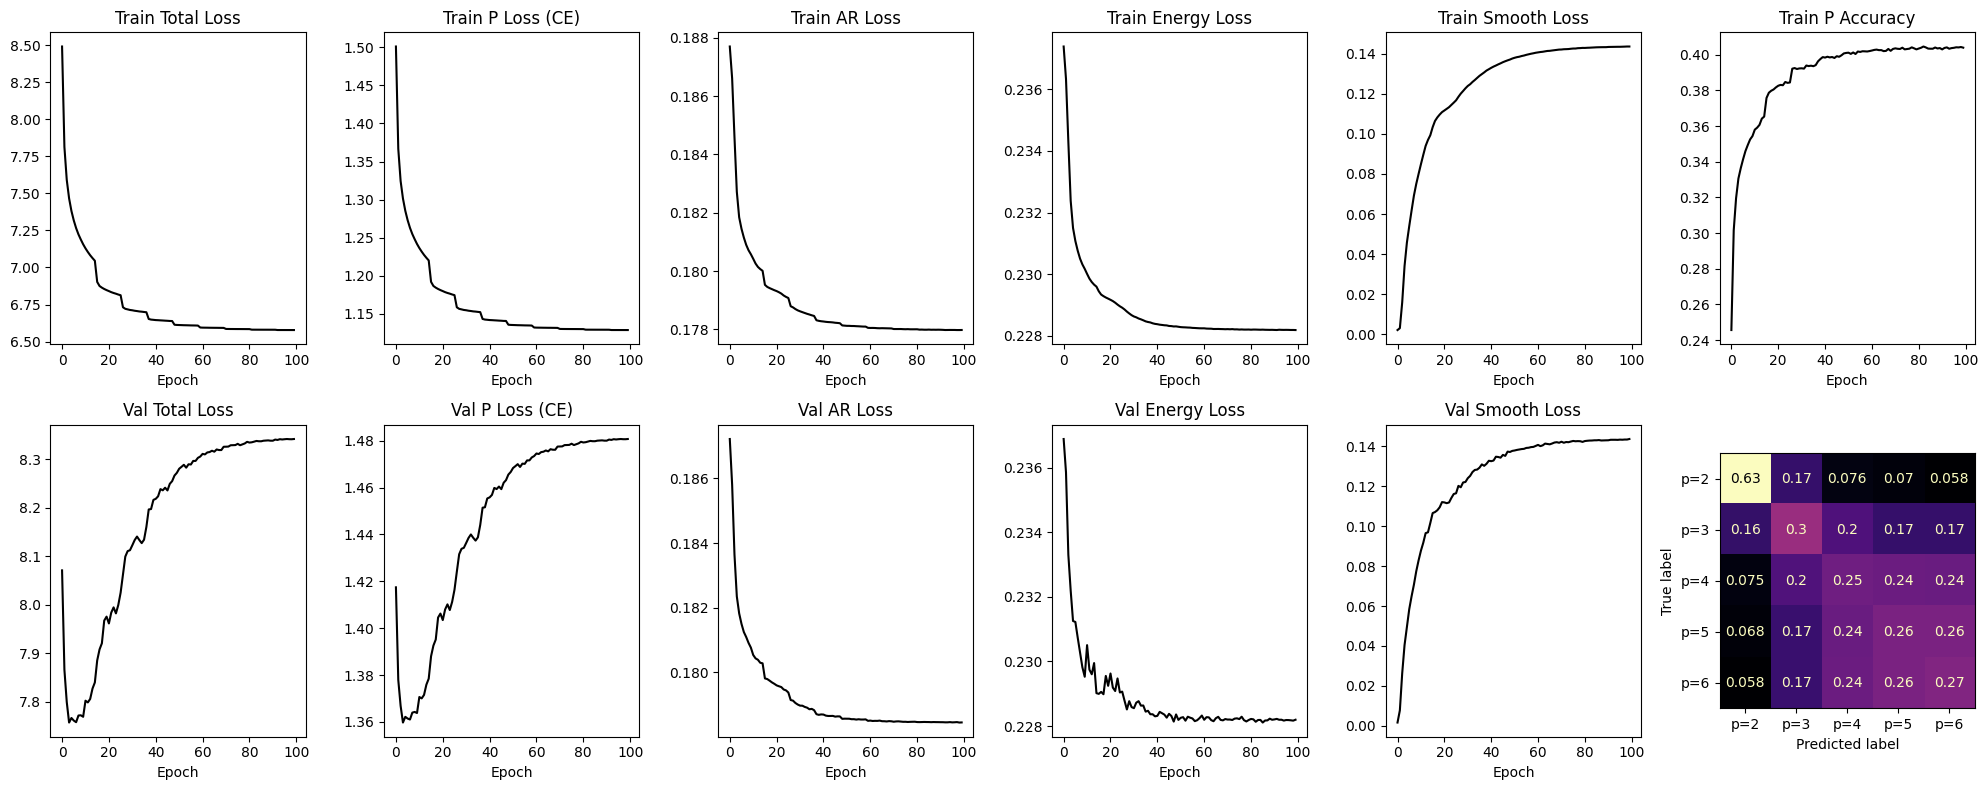

In [26]:
ablation_results = {}
for name, config in ablation_config.items():
    print(f"\n{'='*60}")
    print(f"  Ablation: {name}")
    print(f"  Config: {config}")
    print(f"{'='*60}\n")
    
    model_abl, history_abl = do_bench_on_config(config)
    plot_history(history_abl, model=model_abl, val_loader=val_loader, device=device)
    
    results = bench_loop(model_abl, X_val.cpu(), coef_val[:, :, :6], p_val.cpu(), device)
    ablation_results[name] = results
    
    # Save each model
    torch.save(model_abl.state_dict(), f"ablations/ablation_{name}.pt")

In [27]:
# Build table
ablation_df = pd.DataFrame(ablation_results).T
ablation_df = ablation_df.rename(columns={
    'coeff_mse': 'coeff mse',
    'signal_mse': 'signal mse',
    'p_mae': 'delta p',
    'p_mape': 'delta p / p',
    'p2_acc': 'p=2',
    'p3_acc': 'p=3',
    'p4_acc': 'p=4',
    'p5_acc': 'p=5',
    'p6_acc': 'p=6',
    'p_acc': 'P Avg.',
})

# Save to CSV for easy copy-paste
ablation_df.to_csv("ablation_results.csv")
ablation_df

,coeff mse,signal mse,delta p,delta p / p,p=2,p=3,p=4,p=5,p=6,P Avg.
full,0.004385,0.183794,1.112010,0.301127,0.630825,0.294875,0.248050,0.259025,0.274725,0.341500
no_ar,0.652131,0.747769,1.110445,0.300746,0.630175,0.302550,0.243075,0.262200,0.272850,0.342170
no_p,0.004662,0.183476,1.604880,0.534481,0.010425,0.249200,0.097600,0.285550,0.322975,0.193150
no_energy,0.003757,0.184593,1.107840,0.298853,0.636800,0.297525,0.246700,0.257025,0.272350,0.342080
no_smooth,0.015453,0.178449,1.111215,0.300529,0.630200,0.300150,0.246050,0.255925,0.270750,0.340615


## Models Comparison


In [3]:
import sys
sys.path.insert(0, '/home/rudra/Documents/NeuralFieldManifold')

In [4]:
from NeuralFieldManifold.models import DeepLagEmbed, ARMLP, ARTransformer, AnalyticalAR
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

from NeuralFieldManifold.models import DeepLagEmbed
from NeuralFieldManifold.generators import tvar
from NeuralFieldManifold.utils import train_loop, bench_loop
from NeuralFieldManifold.plottings import plot_history, plot_coefficients_by_p, plot_tvar_sample
from torchinfo import summary

from utils import pinn_processor

In [7]:
X_train, coef_train, p_train, class_id_train, X_val, coef_val, p_val, class_id_val, class_names = pinn_processor("train_data.npz", family=None)

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.cuda.init()
    torch.backends.cudnn.benchmark = True
    print(f"Using device: {device}")

# Move ALL data to GPU upfront - eliminates CPU->GPU transfer bottleneck
X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
p_train = torch.tensor(p_train, dtype=torch.long, device=device)
X_val = torch.tensor(X_val, dtype=torch.float32, device=device)
p_val = torch.tensor(p_val, dtype=torch.long, device=device)
class_id_val = class_id_val  # numpy array

# Data already on GPU - no pin_memory/workers needed
train_loader = DataLoader(
    TensorDataset(X_train, p_train),
    batch_size=len(X_train),  
    shuffle=False             
)

val_loader = DataLoader(
    TensorDataset(X_val, p_val),
    batch_size=len(X_val),
)

Total samples: 1000000 | Train: 800000 | Val: 200000
Train p distribution: {np.int64(0): np.int64(160000), np.int64(1): np.int64(160000), np.int64(2): np.int64(160000), np.int64(3): np.int64(160000), np.int64(4): np.int64(160000)}
Val p distribution:   {np.int64(0): np.int64(40000), np.int64(1): np.int64(40000), np.int64(2): np.int64(40000), np.int64(3): np.int64(40000), np.int64(4): np.int64(40000)}
Using device: cuda:1


### (1) pinn without physics

In [4]:
def do_bench_on_config(lambda_config):
    
    # hyperparameters
    n_epochs = 100
    lr = 1e-3
    max_ar_order = 6
    
    model = DeepLagEmbed(seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128)
    model = model.to(device)

    # summary(model, input_size=(32, 600), device=device)

    # Train
    history = train_loop(
        model, train_loader, val_loader,
        n_epochs=n_epochs, lr=lr,
        lambda_p=lambda_config["lambda_p"], 
        lambda_ar=lambda_config["lambda_ar"], 
        lambda_energy=lambda_config["lambda_energy"],
        lambda_smooth=lambda_config["lambda_smooth"], 
        lambda_order=lambda_config["lambda_order"],
        p_max=max_ar_order, device=device
    )
    return model, history

DeepEmbed Results:


Training: 100%|██████████| 100/100 [14:47<00:00,  8.87s/it, p_acc=0.341, train=5.3861, val=6.8663]


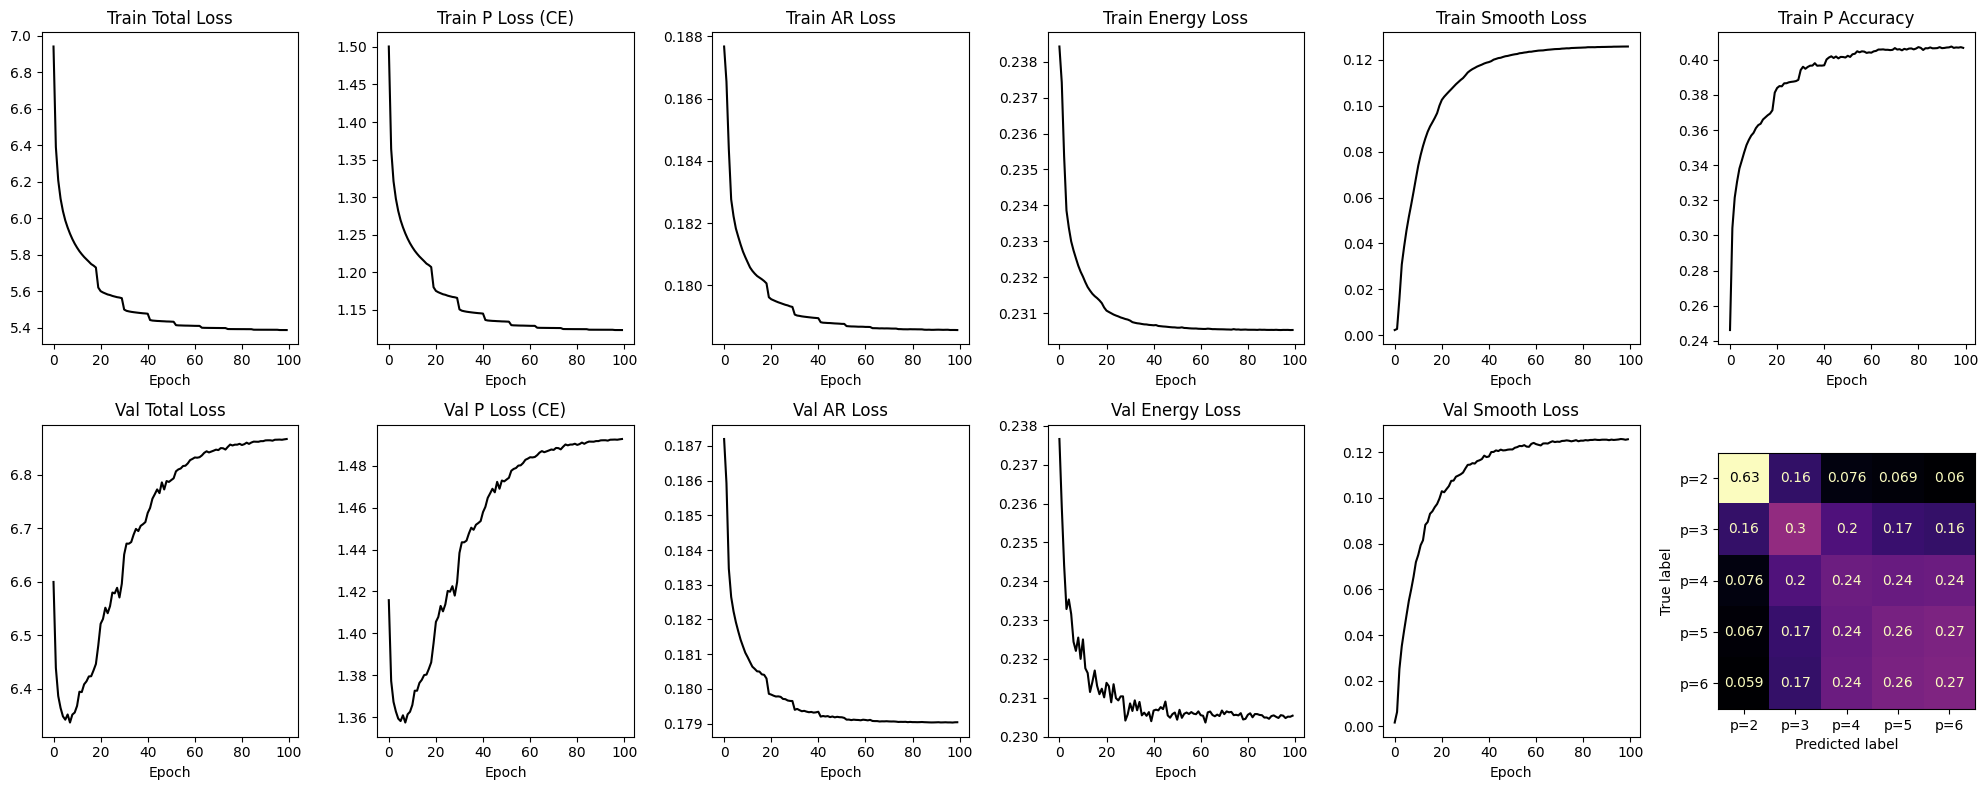

coeff_mse: 0.013391260989010334
signal_mse: 0.17903384566307068
p_mae: 1.10988
p_mape: 0.30026575
p2_acc: 0.6316
p3_acc: 0.295925
p4_acc: 0.2429
p5_acc: 0.2613
p6_acc: 0.2732
p_acc: 0.340985


In [5]:
config = {
    "lambda_ar": 5.0,
    "lambda_p": 4.0,
    "lambda_order": 0,
    "lambda_energy": 0,
    "lambda_smooth": 0
}

print("DeepEmbed Results:")
model, history = do_bench_on_config(config)
plot_history(history, model=model, val_loader=val_loader, device=device)
full_bench_results = bench_loop(model, X_val, coef_val[:, :, :6], p_val, device)
for k, v in full_bench_results.items():
    print(f"{k}: {v}")

### (2) MLP

In [6]:
def do_bench_on_config(lambda_config, model=None):
    
    # hyperparameters
    n_epochs = 100
    lr = 1e-3
    max_ar_order = 6
    
    # Model: n_classes=5 for p∈{2,3,4,5,6}, max_ar_order=6 for coefficient dimensions
    model = ARMLP(seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128)
    model = model.to(device)

    # summary(model, input_size=(32, 600), device=device)

    # Train
    history = train_loop(
        model, train_loader, val_loader,
        n_epochs=n_epochs, lr=lr,
        lambda_p=lambda_config["lambda_p"], lambda_ar=lambda_config["lambda_ar"], lambda_energy=lambda_config["lambda_energy"], 
        lambda_smooth=lambda_config["lambda_smooth"], lambda_order=lambda_config["lambda_order"],
        p_max=max_ar_order, device=device
    )
    return model, history

MLP Results:


Training: 100%|██████████| 100/100 [11:53<00:00,  7.13s/it, p_acc=0.200, train=0.8876, val=0.8888]


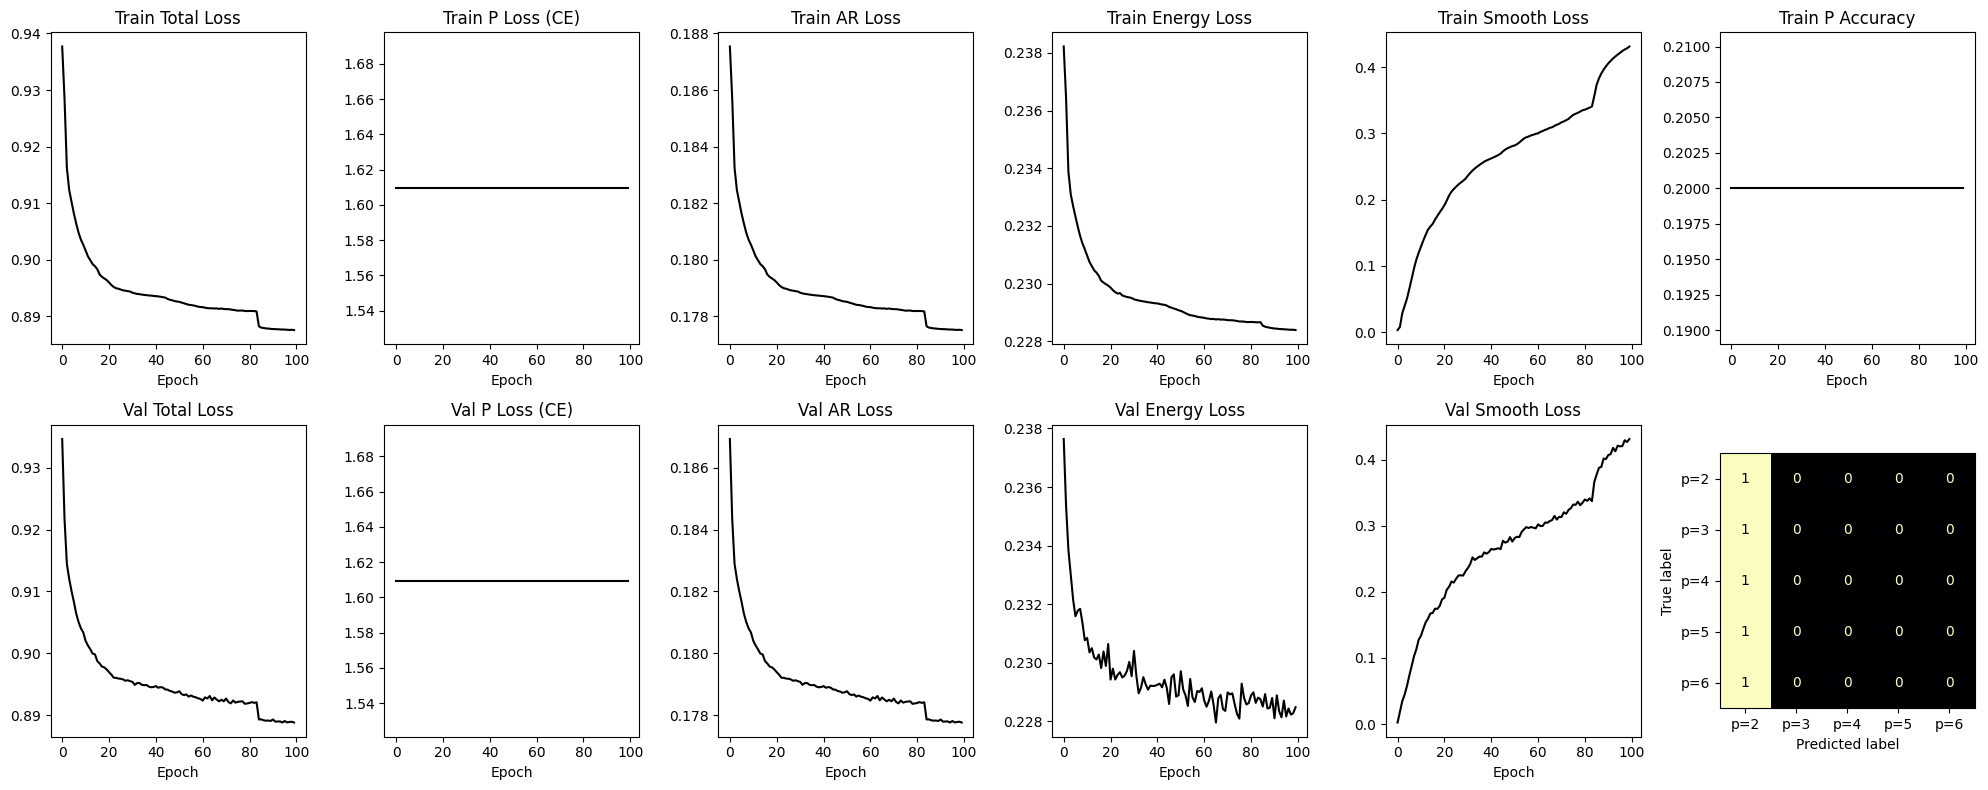

coeff_mse: 0.038411084562540054
signal_mse: 0.17775516211986542
p_mae: 2.0
p_mape: 0.42
p2_acc: 1.0
p3_acc: 0.0
p4_acc: 0.0
p5_acc: 0.0
p6_acc: 0.0
p_acc: 0.2


In [7]:
config = {
    "lambda_ar": 5.0,
    "lambda_p": 0,
    "lambda_order": 0,
    "lambda_energy": 0,
    "lambda_smooth": 0
}

print("MLP Results:")
model, history = do_bench_on_config(config)
plot_history(history, model=model, val_loader=val_loader, device=device)
full_bench_results = bench_loop(model, X_val, coef_val[:, :, :6], p_val, device)
for k, v in full_bench_results.items():
    print(f"{k}: {v}")

### (3) Transformer

In [15]:
def do_bench_on_config(lambda_config):
    
    # hyperparameters
    n_epochs = 20
    lr = 1e-3
    max_ar_order = 6
    
    # Model: n_classes=5 for p∈{2,3,4,5,6}, max_ar_order=6 for coefficient dimensions
    model = ARTransformer(seq_len=600, n_classes=5, max_ar_order=6, d_model=64, nhead=4, num_layers=2)
    model = model.to(device)

    # summary(model, input_size=(32, 600), device=device)

    # Train
    history = train_loop(
        model, train_loader, val_loader,
        n_epochs=n_epochs, lr=lr,
        lambda_p=lambda_config["lambda_p"], 
        lambda_ar=lambda_config["lambda_ar"], 
        lambda_energy=lambda_config["lambda_energy"],
        lambda_smooth=lambda_config["lambda_smooth"], 
        lambda_order=lambda_config["lambda_order"],
        p_max=max_ar_order, device=device
    )
    return model, history

In [ ]:
config = {
    "lambda_ar": 5.0,
    "lambda_p": 0,
    "lambda_order": 0,
    "lambda_energy": 0,
    "lambda_smooth": 0
}

print("Transformer Results:")
model, history = do_bench_on_config(config)
plot_history(history, model=model, val_loader=val_loader, device=device)
full_bench_results = bench_loop(model, X_val, coef_val[:, :, :6], p_val, device)
for k, v in full_bench_results.items():
    print(f"{k}: {v}")

Transformer Results:


### (4) OLS

In [5]:
def do_bench_on_config(lambda_config, model=None):
    
    # hyperparameters
    n_epochs = 1
    lr = 1e-3
    max_ar_order = 6
    
    if model is None:
        # Model: n_classes=5 for p∈{2,3,4,5,6}, max_ar_order=6 for coefficient dimensions
        model = AnalyticalAR(seq_len=600, n_classes=5, max_ar_order=6)
        model = model.to(device)
        # summary(model, input_size=(32, 600), device=device)

    # Train
    history = train_loop(
        model, train_loader, val_loader,
        n_epochs=n_epochs, lr=lr,
        lambda_p=lambda_config["lambda_p"], lambda_ar=lambda_config["lambda_ar"], lambda_energy=lambda_config["lambda_energy"], 
        lambda_smooth=lambda_config["lambda_smooth"], lambda_order=lambda_config["lambda_order"],
        p_max=max_ar_order, device=device
    )
    return model, history

OLS Results:


Training: 100%|██████████| 1/1 [00:21<00:00, 21.77s/it, p_acc=0.200, train=0.9159, val=0.9163]


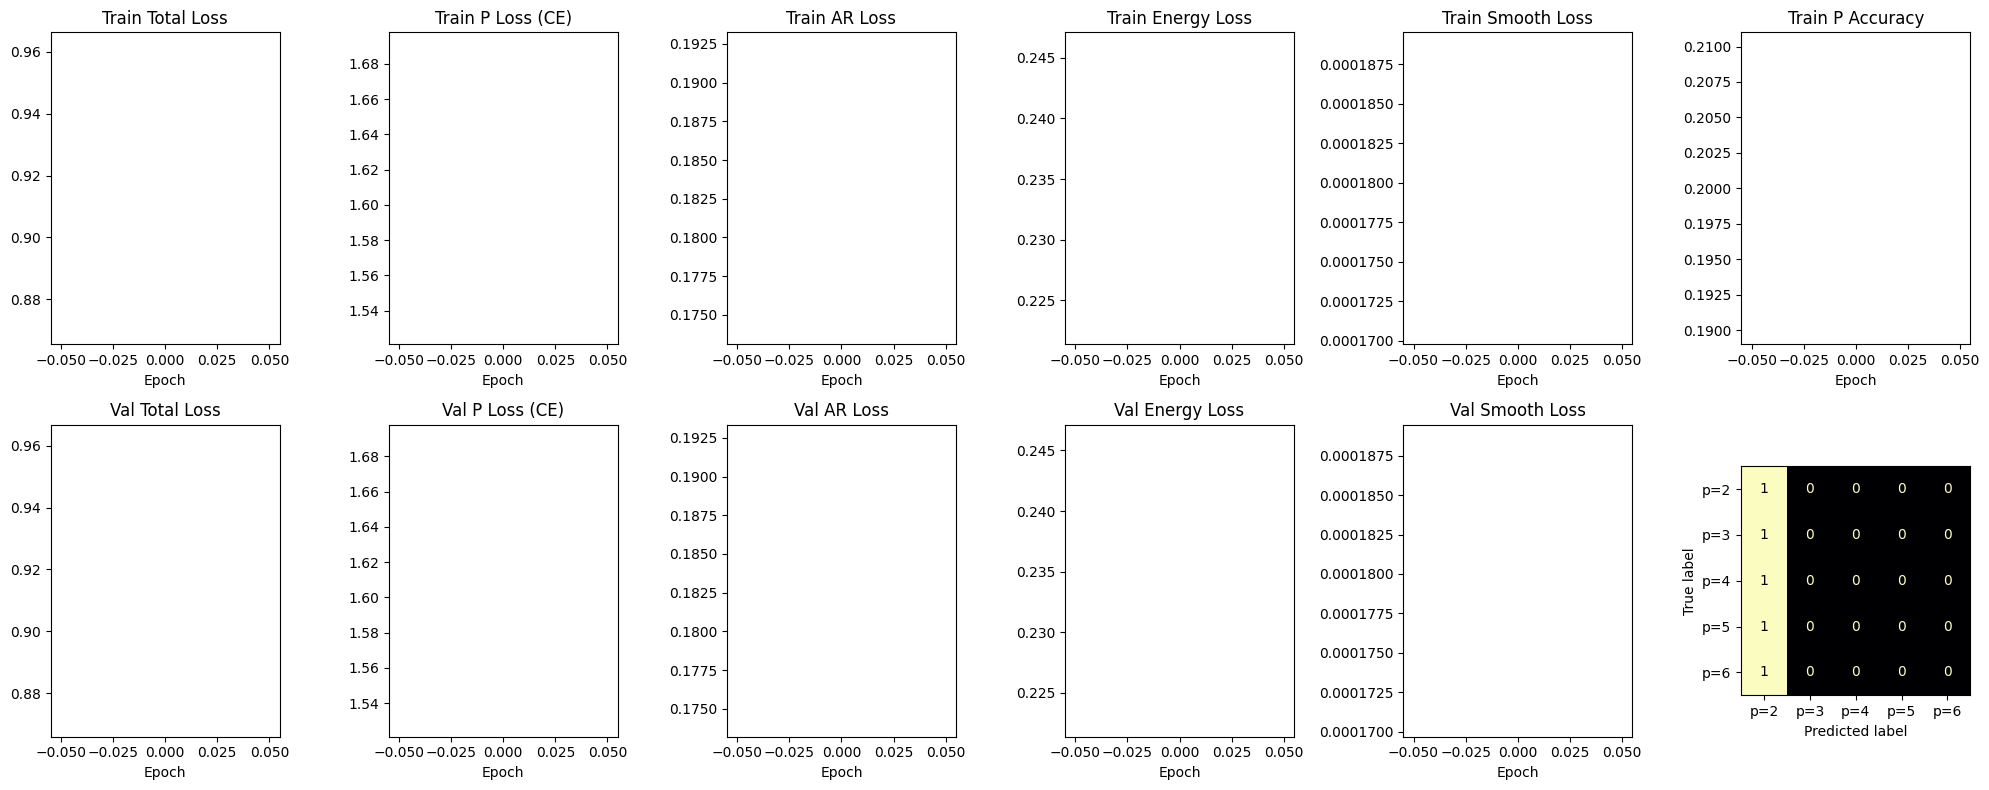

coeff_mse: 0.004037843551486731
signal_mse: 0.18326832354068756
p_mae: 2.0
p_mape: 0.42
p2_acc: 1.0
p3_acc: 0.0
p4_acc: 0.0
p5_acc: 0.0
p6_acc: 0.0
p_acc: 0.2


In [8]:
config = {
    "lambda_ar": 5.0,
    "lambda_p": 0,
    "lambda_order": 0,
    "lambda_energy": 0,
    "lambda_smooth": 0
}

print("OLS Results:")
device = 'cpu'
model, history = do_bench_on_config(config)
plot_history(history, model=model, val_loader=val_loader, device=device)
full_bench_results = bench_loop(model, X_val, coef_val[:, :, :6], p_val, device)
for k, v in full_bench_results.items():
    print(f"{k}: {v}")

In [9]:
# Check how much coefficients actually vary over time
coef_var = np.mean(np.var(coef_val, axis=1))  # variance across time
coef_mean_sq = np.mean(np.mean(coef_val, axis=1)**2)  # mean magnitude
print(f"Avg temporal variance: {coef_var:.6f}")
print(f"Avg mean^2: {coef_mean_sq:.6f}")
print(f"Ratio (variation/mean): {coef_var/coef_mean_sq:.4f}")

Avg temporal variance: 0.001020
Avg mean^2: 0.006861
Ratio (variation/mean): 0.1487
